# Student Credit Risk Assessment
## Logistic Regression Baseline

This notebook develops the Logistic Regression baseline model for the Student Credit Risk Assessment project. It uses the final post-EDA dataset and serves as the reference model for evaluating subsequent machine learning approaches.

## 1. Project Context



This notebook develops the **Logistic Regression baseline model** for the Student Credit Risk Assessment project using the final post-EDA modelling dataset. As the first baseline model in the research pipeline, it establishes an interpretable benchmark against which subsequent machine learning models and the Nemotron reasoning model can be systematically evaluated.





### 1.1 Problem Statement

Financial institutions often encounter **thin-file borrowers**, particularly students with limited credit histories, making conventional credit risk assessment challenging. Inaccurate risk estimation may result in increased default rates, reduced financial inclusion, or overly conservative lending practices.

This notebook addresses the binary classification problem of predicting whether a borrower is likely to default (`default_flag`) using demographic, academic, financial, behavioural, and banking-related features derived during the data generation and exploratory data analysis stages.





### 1.2 Why Logistic Regression?

Logistic Regression is selected as the first baseline model due to its simplicity, computational efficiency, and high interpretability. Unlike more complex machine learning algorithms, Logistic Regression provides directly interpretable coefficients that quantify the influence of individual features on the predicted probability of default.

As a widely accepted baseline classifier in credit risk modelling, it establishes a transparent benchmark against which the performance, robustness, fairness, and explainability of more advanced models can be evaluated throughout this research.





### 1.3 Research Objectives

The primary objectives of this notebook are to:

- Develop a reproducible Logistic Regression baseline for student credit risk prediction.
- Evaluate model performance under three experimental data-splitting strategies.
- Compare baseline and hyperparameter-tuned model performance.
- Analyse feature contributions using coefficient interpretation and SHAP explanations.
- Assess fairness across selected demographic groups.
- Compare the behaviour of Logistic Regression with the Nemotron reasoning model.





### 1.4 Expected Outcomes

By the completion of this notebook, the following outcomes are expected:

- A validated Logistic Regression baseline model.
- Performance evaluation across three experimental strategies.
- Comparative analysis between baseline and tuned configurations.
- Identification of influential predictive features.
- Assessment of model interpretability and fairness.
- Comparative insights against the Nemotron reasoning model.



## 2. Dataset Foundation

This section loads and verifies the final modelling dataset before feature selection and preprocessing. The objective is to confirm that the dataset has been imported correctly, follows the expected schema, and is ready for subsequent modelling stages.

### 2.1 Import Libraries

In [1]:
# ==========================================================
# 2.1 Import Libraries
# ==========================================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("default")
sns.set_theme(style="whitegrid")

### 2.2 Load Dataset

In [2]:
# ==========================================================
# 2.2 Load Dataset
# ==========================================================

DATA_PATH = "../data/master_v6_post_eda.csv"

TARGET_COLUMN = "default_flag"

IDENTIFIER_COLUMNS = [
    "student_id"
]

LEAKAGE_COLUMNS = [
    "default_probability"
]

RANDOM_STATE = 42

student_df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {student_df.shape}")

display(student_df.head())

Dataset Shape : (21000, 38)


,student_id,synthetic_age,enrollment_type,academic_year,major_category,gpa_direction,credit_hours_current,semesters_enrolled,expected_total_semesters,remaining_semesters,monthly_inflow_mean,cash_flow_cv,aid_disbursement_flag,aid_amount,estimated_tuition,estimated_living_cost,synthetic_debt_load,campus_employment,gig_income_flag,bill_payment_rate,savings_behavior,subscription_count,prior_delinquency,application_week,semester_phase,academic_calendar_flag,ecs,gdi,acr,cfri,opr,tgb,spra,sei,default_probability,default_flag,credit_bin,synthetic_anomaly_flag
0,STU_002313,21.9141,Full-time,2,Business,Stable,13.3372,4,8,4,993.4006,0.7318,0,0.0000,4636.5845,6660.3798,6640.0101,0,1,0.8795,Sporadic,3,0,9,Early,1,0.5000,0.0000,0.3517,0.2682,0.8795,0.1829,0.3289,0.3259,0.0341,0,12-15 (Full),0
1,STU_016846,22.0878,Full-time,3,Arts,Stable,16.3653,5,8,3,2834.8034,0.1298,1,4725.6159,8071.4889,3797.3567,12767.0852,0,1,0.6724,Sporadic,0,0,6,Late,1,0.6250,0.0000,1.3535,0.8702,0.6724,0.1466,0.1502,0.8643,0.0046,0,15+ (Overload),0
2,STU_006106,23.4131,Full-time,2,Business,Stable,17.8260,4,8,4,530.2470,0.1648,1,6628.3747,6700.1349,3990.6708,5113.1182,0,0,0.8811,Sporadic,2,0,10,Early,1,0.5000,0.0000,0.8184,0.8352,0.8811,0.1885,0.1016,0.5592,0.0042,0,15+ (Overload),0
3,STU_018083,20.7062,Full-time,2,STEM,Stable,15.0142,3,8,5,959.2160,0.0678,1,3527.0611,8437.0759,5858.2115,5245.2304,0,1,0.9265,No Savings,2,0,5,Mid,1,0.3750,0.0000,0.5151,0.9322,0.9265,0.2092,0.0492,0.3701,0.0062,0,15+ (Overload),0
4,STU_011336,19.7460,Part-time,2,Business,Declining,7.0056,3,10,7,1475.7728,0.2107,0,0.0000,7062.3194,4216.9331,6813.0712,1,0,0.8544,Sporadic,5,0,4,Mid,1,0.3000,-1.0000,0.5234,0.7893,0.8544,0.2356,0.1279,0.1517,0.0881,0,6-11 (Half),0


### 2.3 Dataset Overview

In [3]:
# ==========================================================
# 2.3 Dataset Overview
# ==========================================================

display(student_df.describe().T)

display(student_df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
synthetic_age,21000.0000,21.5256,1.7602,18.0000,20.2972,21.5093,22.7265,29.5624
academic_year,21000.0000,2.4066,1.0111,1.0000,2.0000,2.0000,3.0000,4.0000
credit_hours_current,21000.0000,13.4476,2.7659,3.0000,12.0000,13.7395,15.3322,19.0000
semesters_enrolled,21000.0000,4.2355,1.9720,1.0000,3.0000,4.0000,6.0000,8.0000
expected_total_semesters,21000.0000,8.4166,1.0692,8.0000,8.0000,8.0000,8.0000,12.0000
remaining_semesters,21000.0000,4.1811,2.2257,1.0000,2.0000,4.0000,6.0000,11.0000
monthly_inflow_mean,21000.0000,1314.3130,544.8404,265.6408,925.7381,1210.8788,1591.7095,7516.4249
cash_flow_cv,21000.0000,0.2849,0.1595,0.0026,0.1611,0.2642,0.3870,0.9055
aid_disbursement_flag,21000.0000,0.6489,0.4773,0.0000,0.0000,1.0000,1.0000,1.0000
aid_amount,21000.0000,3080.9336,2599.2379,0.0000,0.0000,3268.6793,5363.0736,7499.9704


,count,unique,top,freq
student_id,21000,21000,STU_002313,1
enrollment_type,21000,2,Full-time,17895
major_category,21000,4,STEM,8340
gpa_direction,21000,3,Stable,9453
savings_behavior,21000,3,Sporadic,9413
semester_phase,21000,3,Mid,10598
credit_bin,21000,4,12-15 (Full),11619


### 2.4 Dataset Structure

In [4]:
# ==========================================================
# 2.4 Dataset Structure
# ==========================================================

student_df.info()

duplicate_rows = student_df.duplicated().sum()
missing_values = student_df.isna().sum().sum()

print(f"\nDuplicate Rows : {duplicate_rows}")
print(f"Missing Values : {missing_values}")


print(f"Target Column : '{TARGET_COLUMN}'")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                21000 non-null  object 
 1   synthetic_age             21000 non-null  float64
 2   enrollment_type           21000 non-null  object 
 3   academic_year             21000 non-null  int64  
 4   major_category            21000 non-null  object 
 5   gpa_direction             21000 non-null  object 
 6   credit_hours_current      21000 non-null  float64
 7   semesters_enrolled        21000 non-null  int64  
 8   expected_total_semesters  21000 non-null  int64  
 9   remaining_semesters       21000 non-null  int64  
 10  monthly_inflow_mean       21000 non-null  float64
 11  cash_flow_cv              21000 non-null  float64
 12  aid_disbursement_flag     21000 non-null  int64  
 13  aid_amount                21000 non-null  float64
 14  estima

### 2.5 Target Variable Analysis

In [5]:
target_summary = (
    student_df[TARGET_COLUMN]
    .value_counts()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] /
    len(student_df) * 100
).round(2)

display(target_summary)


,default_flag,Count,Percentage
0,0,20318,96.7500
1,1,682,3.2500


### 2.6 Dataset Summary

In [6]:
# ==========================================================
# 2.6 Dataset Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Duplicate Rows",
            "Missing Values",
        ],
        "Value": [
            student_df.shape[0],
            student_df.shape[1],
            duplicate_rows,
            missing_values,
        ],
    }
)

display(summary)

,Metric,Value
0,Rows,21000
1,Columns,38
2,Duplicate Rows,0
3,Missing Values,0


### 2.7 Findings 
The modelling dataset was successfully loaded and verified. Structural validation confirmed the expected schema, the target variable was identified successfully, and no duplicate records or missing values were detected. The dataset is ready for feature validation and selection.

## 3. Feature Validation & Selection

### 3.1 Feature Selection Objective

Establish a common modelling feature set for all machine learning models by removing leakage variables, identifier columns, synthetic diagnostic attributes, and redundant features identified during the EDA.

### 3.2 Remove Leakage Features

In [7]:
# ==========================================================
# 3.2 Remove Leakage Features
# ==========================================================

processed_df = student_df.drop(columns=LEAKAGE_COLUMNS).copy()

print(f"Removed Leakage Columns : {LEAKAGE_COLUMNS}")

print(f"Dataset Shape : {processed_df.shape}")

Removed Leakage Columns : ['default_probability']
Dataset Shape : (21000, 37)


### 3.3 Remove Identifier Features

In [8]:
# ==========================================================
# 3.3 Remove Identifier Features
# ==========================================================

processed_df.drop(columns=IDENTIFIER_COLUMNS, inplace=True)

print(f"Removed Identifier Columns : {IDENTIFIER_COLUMNS}")

print(f"Dataset Shape : {processed_df.shape}")

Removed Identifier Columns : ['student_id']
Dataset Shape : (21000, 36)


### 3.4 Feature Validation


Feature selection decisions are guided by three principles:

- Leakage and identifier variables are removed.
- Redundant representations identified during exploratory data analysis are eliminated.
- Engineered features are retained where they provide a more suitable representation of the underlying concept for modelling.

The final feature set is established once and reused across every machine learning model to ensure a fair comparison.

In [9]:
# ==========================================================
# 3.4 Feature Validation
# ==========================================================

feature_decisions = pd.DataFrame(
    {
        "Feature": [
            "student_id",
            "default_probability",
            "synthetic_anomaly_flag",
            "expected_total_semesters",
            "remaining_semesters",
            "gpa_direction",
            "bill_payment_rate",
            "cash_flow_cv",
            "credit_bin"
        ],
        "Decision": [
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove"
        ],
        "Reason": [
            "Identifier",
            "Target Leakage",
            "Synthetic Diagnostic",
            "Redundant Temporal Feature",
            "Redundant Temporal Feature",
            "Represented by GDI",
            "Represented by OPR",
            "Represented by CFRI",
            "Is an interpreter of credit_hours_current"
        ]
    }
)

display(feature_decisions)

,Feature,Decision,Reason
0,student_id,Remove,Identifier
1,default_probability,Remove,Target Leakage
2,synthetic_anomaly_flag,Remove,Synthetic Diagnostic
3,expected_total_semesters,Remove,Redundant Temporal Feature
4,remaining_semesters,Remove,Redundant Temporal Feature
5,gpa_direction,Remove,Represented by GDI
6,bill_payment_rate,Remove,Represented by OPR
7,cash_flow_cv,Remove,Represented by CFRI
8,credit_bin,Remove,Is an interpreter of credit_hours_current


In [10]:
# ==========================================================
# Apply Feature Selection
# ==========================================================

FEATURES_TO_REMOVE = feature_decisions.loc[
    feature_decisions["Decision"] == "Remove",
    "Feature"
].tolist()

processed_df.drop(
    columns=FEATURES_TO_REMOVE,
    inplace=True,
    errors="ignore"
)

print(f"Remaining Features : {processed_df.shape[1]}")

Remaining Features : 29


### 3.5 Selected Feature Set

In [11]:
selected_features = processed_df.drop(
    columns=TARGET_COLUMN
).columns.tolist()

display(
    pd.DataFrame(
        selected_features,
        columns=["Feature"]
    )
)

,Feature
0,synthetic_age
1,enrollment_type
2,academic_year
3,major_category
4,credit_hours_current
5,semesters_enrolled
6,monthly_inflow_mean
7,aid_disbursement_flag
8,aid_amount
9,estimated_tuition


### 3.6 Feature Selection Summary



Feature selection was performed using a combination of deterministic removal, exploratory data analysis and domain knowledge. Leakage variables, identifier columns and redundant feature representations were excluded to obtain a consistent modelling dataset.

The resulting feature set will be reused across every machine learning model to ensure a fair comparison throughout this study.

In [12]:
# ==========================================================
# 3.6 Feature Selection Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Initial Features",
            "Removed Features",
            "Final Features",
            "Target Variable"
        ],
        "Value": [
            student_df.shape[1] - 1,
            len(FEATURES_TO_REMOVE),
            len(selected_features),
            TARGET_COLUMN
        ]
    }
)

display(summary)

,Metric,Value
0,Initial Features,37
1,Removed Features,9
2,Final Features,28
3,Target Variable,default_flag


### 3.7 Findings



- Leakage, identifier and redundant features were removed before model development.
- The final feature set combines original and engineered variables while avoiding duplicate representations.
- A common feature set has been established and will be used across all machine learning models to ensure a consistent experimental comparison.

## 4. Preprocessing

### 4.1 Preprocessing Objective



Following feature selection, the modelling dataset is verified before preparing model inputs. This section confirms that the remaining features are correctly classified, contain no missing values and have appropriate data types for subsequent transformations.

No feature engineering or transformations are performed in this section.

### 4.2 Feature Classification

In [13]:
# ==========================================================
# 4.2 Feature Classification
# ==========================================================

categorical_features = [
    column
    for column in processed_df.select_dtypes(include="object").columns
    if column != TARGET_COLUMN
]

numerical_features = [
    column
    for column in processed_df.select_dtypes(include=["int64", "float64"]).columns
    if column != TARGET_COLUMN
]

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

print("\nNumerical Features")
print("------------------")
print(numerical_features)

print("\nCategorical Features")
print("--------------------")
print(categorical_features)

Numerical Features   : 24
Categorical Features : 4

Numerical Features
------------------
['synthetic_age', 'academic_year', 'credit_hours_current', 'semesters_enrolled', 'monthly_inflow_mean', 'aid_disbursement_flag', 'aid_amount', 'estimated_tuition', 'estimated_living_cost', 'synthetic_debt_load', 'campus_employment', 'gig_income_flag', 'subscription_count', 'prior_delinquency', 'application_week', 'academic_calendar_flag', 'ecs', 'gdi', 'acr', 'cfri', 'opr', 'tgb', 'spra', 'sei']

Categorical Features
--------------------
['enrollment_type', 'major_category', 'savings_behavior', 'semester_phase']


### 4.3 Missing Value Verification

In [14]:
# ==========================================================
# 4.3 Missing Value Verification
# ==========================================================

missing_values = processed_df.isna().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)

No missing values found.


### 4.4 Data Type Verification

In [15]:
# ==========================================================
# 4.4 Data Type Verification
# ==========================================================

dtype_summary = pd.DataFrame(
    {
        "Feature": processed_df.columns,
        "Data Type": processed_df.dtypes.astype(str).values
    }
)

display(dtype_summary)

,Feature,Data Type
0,synthetic_age,float64
1,enrollment_type,object
2,academic_year,int64
3,major_category,object
4,credit_hours_current,float64
5,semesters_enrolled,int64
6,monthly_inflow_mean,float64
7,aid_disbursement_flag,int64
8,aid_amount,float64
9,estimated_tuition,float64


### 4.5 Preprocessing Summary

In [16]:
# ==========================================================
# 4.5 Preprocessing Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Total Features",
            "Numerical Features",
            "Categorical Features",
            "Missing Values"
        ],
        "Value": [
            processed_df.shape[1] - 1,
            len(numerical_features),
            len(categorical_features),
            processed_df.isna().sum().sum()
        ]
    }
)

display(summary)

,Metric,Value
0,Total Features,28
1,Numerical Features,24
2,Categorical Features,4
3,Missing Values,0


### 4.6 Findings

- The modelling dataset was successfully validated after feature selection.
- No missing values or data type inconsistencies were identified.
- The dataset is ready for model input preparation and feature transformation.

## 5. Model Preparation

### 5.1 Model Preparation Objective

The validated feature set is converted into model inputs required for Logistic Regression. This section defines the predictor matrix, target variable, training and testing datasets, and applies the transformations necessary for numerical optimisation while preserving the experimental protocol established for the study.

### 5.2 Feature Matrix (X, y)

In [17]:
# ==========================================================
# 5.2 Feature Matrix (X, y)
# ==========================================================

X = processed_df.drop(columns=TARGET_COLUMN)

y = processed_df[TARGET_COLUMN]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (21000, 28)
Target Shape         : (21000,)


### 5.3 Train-Test Split

In [18]:
# ==========================================================
# 5.3 Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 16800
Testing Samples  : 4200


### 5.4 Feature Transformation



Logistic Regression requires numerical inputs and benefits from feature scaling. Categorical variables are encoded and numerical variables are standardised using statistics computed from the training dataset only to avoid data leakage.

In [19]:
# ==========================================================
# 5.4 Feature Transformation
# ==========================================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

scaler = StandardScaler()

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

### 5.5 Model Input Preparation

In [20]:
# ==========================================================
# 5.5 Model Input Preparation
# ==========================================================


X_train_final = np.hstack(
    [X_train_num, X_train_cat]
)

X_test_final = np.hstack(
    [X_test_num, X_test_cat]
)

print(f"Training Matrix : {X_train_final.shape}")
print(f"Testing Matrix  : {X_test_final.shape}")

Training Matrix : (16800, 36)
Testing Matrix  : (4200, 36)


### 5.6 Preparation Summary

In [21]:
# ==========================================================
# 5.6 Preparation Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Training Samples",
            "Testing Samples",
            "Numerical Features",
            "Categorical Features",
            "Encoded Features"
        ],
        "Value": [
            X_train.shape[0],
            X_test.shape[0],
            len(numerical_features),
            len(categorical_features),
            X_train_final.shape[1]
        ]
    }
)

display(summary)

,Metric,Value
0,Training Samples,16800
1,Testing Samples,4200
2,Numerical Features,24
3,Categorical Features,4
4,Encoded Features,36


### 5.7 Findings



- The modelling dataset was partitioned using a stratified train-test split.
- Categorical variables were encoded and numerical variables were standardised using only the training data.
- The transformed feature matrices are now ready for experimental evaluation using Logistic Regression.

## 6. Experimental Design

### 6.1 Experimental Objective



The objective of this section is to define the experimental protocol used to evaluate Logistic Regression. Multiple train-test strategies are considered to assess the robustness of the model under different data partitioning scenarios while maintaining a consistent evaluation methodology across all machine learning models.

No model training is performed in this section.

### 6.2 Experiment 1 – Stratified Split

Experiment 1 represents the baseline evaluation strategy. The dataset is partitioned using a stratified train-test split, ensuring that the class distribution of the target variable is preserved in both subsets. This experiment provides the primary benchmark for subsequent comparisons.

### 6.3 Experiment 2 – Semester-aware Stratified Split

Experiment 2 extends the baseline strategy by maintaining both the target class distribution and a balanced academic semester distribution across the training and testing datasets. This experiment evaluates whether maintaining comparable academic progression improves model generalisation.

### 6.4 Experiment 3 – Temporal Split

Experiment 3 evaluates model performance under a chronological training strategy. Earlier academic periods are used for training while later periods are reserved for testing, simulating a realistic deployment scenario where future student outcomes must be predicted using historical observations.

### 6.5 Evaluation Metrics

In [22]:
# ==========================================================
# 6.5 Evaluation Metrics
# ==========================================================

evaluation_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
            "PR-AUC"
        ],
        "Purpose": [
            "Overall classification performance",
            "Positive prediction reliability",
            "Default detection capability",
            "Balance between precision and recall",
            "Overall discrimination ability",
            "Performance under class imbalance"
        ]
    }
)

display(evaluation_metrics)

,Metric,Purpose
0,Accuracy,Overall classification performance
1,Precision,Positive prediction reliability
2,Recall,Default detection capability
3,F1-Score,Balance between precision and recall
4,ROC-AUC,Overall discrimination ability
5,PR-AUC,Performance under class imbalance


### 6.6 Cross-Validation Strategy

Model selection and hyperparameter optimisation will use Stratified K-Fold Cross-Validation to preserve the target class distribution within each fold. Five-fold cross-validation will be adopted as the primary validation strategy.

In [23]:
# ==========================================================
# 6.6 Cross-Validation Strategy
# ==========================================================

from sklearn.model_selection import StratifiedKFold

cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



print("Cross-Validation : 5-Fold Stratified")


Cross-Validation : 5-Fold Stratified


### 6.7 Hyperparameter Optimisation Strategy

Hyperparameter optimisation will be performed after establishing the baseline performance for each experiment. Grid Search combined with Stratified Cross-Validation will be used to identify the optimal parameter configuration while ensuring a fair comparison between the baseline and tuned models.

### 6.8 Experimental Summary

In [24]:
# ==========================================================
# 6.8 Experimental Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Component": [
            "Experiments",
            "Train-Test Strategies",
            "Cross-Validation",
            "Hyperparameter Search",
            "Evaluation Metrics"
        ],
        "Configuration": [
            "3",
            "Stratified, Semester-aware, Temporal",
            "5-Fold Stratified",
            "Grid Search",
            "Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC"
        ]
    }
)

display(summary)

,Component,Configuration
0,Experiments,3
1,Train-Test Strategies,"Stratified, Semester-aware, Temporal"
2,Cross-Validation,5-Fold Stratified
3,Hyperparameter Search,Grid Search
4,Evaluation Metrics,"Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC"


### 6.9 Findings

- Three experimental settings have been defined to evaluate Logistic Regression under different data partitioning strategies.
- Performance will be assessed using multiple complementary evaluation metrics rather than a single metric.
- Cross-validation and hyperparameter optimisation are incorporated to improve the robustness and reliability of model comparison.

## 7. Experiment Execution

### 7.1 Experiment Execution Objective



This section implements the experimental protocol defined previously. Each experiment is evaluated using two configurations: a baseline Logistic Regression model with default parameters and a tuned model obtained through Grid Search with Stratified Cross-Validation.

The objective is to assess the impact of different data partitioning strategies and hyperparameter optimisation on model performance.

### 7.2 Experiment 1 – Baseline

In [25]:
# ==========================================================
# 7.2 Experiment 1 - Baseline
# ==========================================================

from sklearn.linear_model import LogisticRegression

baseline_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_lr.fit(
    X_train_final,
    y_train
)

baseline_predictions = baseline_lr.predict(X_test_final)

baseline_probabilities = baseline_lr.predict_proba(
    X_test_final
)[:, 1]

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


### 7.3 Experiment 1 – Tuned

In [26]:
# ==========================================================
# 7.3 Experiment 1 - Tuned
# ==========================================================

from sklearn.model_selection import GridSearchCV

parameter_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=parameter_grid,
    cv=cv_5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train_final,
    y_train
)

tuned_lr = grid_search.best_estimator_

tuned_predictions = tuned_lr.predict(
    X_test_final
)

tuned_probabilities = tuned_lr.predict_proba(
    X_test_final
)[:, 1]

print("Best Parameters")
print(grid_search.best_params_)

Best Parameters
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


### 7.4 Experiment 2 – Baseline

This experiment will evaluate Logistic Regression using the semester-aware stratified split defined in Section 6. The implementation will follow the same workflow as Experiment 1 after the custom splitting strategy is established.

In [27]:
# ==========================================================
# 7.4 Semester-aware Stratified Split
# ==========================================================

semester_groups = (
    processed_df["semesters_enrolled"].astype(str)
    + "_"
    + processed_df[TARGET_COLUMN].astype(str)
)

X_sem = processed_df.drop(columns=TARGET_COLUMN)
y_sem = processed_df[TARGET_COLUMN]

X_train_sem, X_test_sem, y_train_sem, y_test_sem = train_test_split(
    X_sem,
    y_sem,
    test_size=0.20,
    stratify=semester_groups,
    random_state=42
)

print(f"Training Samples : {len(X_train_sem)}")
print(f"Testing Samples  : {len(X_test_sem)}")

Training Samples : 16800
Testing Samples  : 4200


In [28]:

semester_distribution = pd.DataFrame({
    "Overall": (
        processed_df["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "Train": (
        X_train_sem["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "Test": (
        X_test_sem["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    )
})

display(semester_distribution.style.format("{:.2%}"))

,Overall,Train,Test
semesters_enrolled,,,
1,11.18%,11.18%,11.17%
2,10.72%,10.73%,10.71%
3,16.64%,16.64%,16.64%
4,16.03%,16.04%,16.02%
5,14.11%,14.11%,14.12%
6,14.16%,14.16%,14.17%
7,15.83%,15.83%,15.83%
8,1.31%,1.31%,1.33%


The semester-aware stratified split successfully preserved the academic semester distribution across the training and testing datasets. The proportion of observations in each semester remained nearly identical to the overall dataset while simultaneously maintaining the target class distribution. This confirms that the alternative partitioning strategy satisfies the intended experimental design.

In [29]:
# ==========================================================
# 7.4 Experiment 2 Baseline
# ==========================================================

X_train_sem_cat = encoder.fit_transform(
    X_train_sem[categorical_features]
)

X_test_sem_cat = encoder.transform(
    X_test_sem[categorical_features]
)

X_train_sem_num = scaler.fit_transform(
    X_train_sem[numerical_features]
)

X_test_sem_num = scaler.transform(
    X_test_sem[numerical_features]
)

X_train_sem_final = np.hstack(
    (X_train_sem_num, X_train_sem_cat)
)

X_test_sem_final = np.hstack(
    (X_test_sem_num, X_test_sem_cat)
)

baseline_lr_sem = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_lr_sem.fit(
    X_train_sem_final,
    y_train_sem
)

baseline_sem_predictions = baseline_lr_sem.predict(
    X_test_sem_final
)

baseline_sem_probabilities = baseline_lr_sem.predict_proba(
    X_test_sem_final
)[:, 1]

print("Experiment 2 Baseline Completed")

Experiment 2 Baseline Completed


### 7.5 Experiment 2 – Tuned

In [30]:
# ==========================================================
# 7.5 Experiment 2 Tuned
# ==========================================================

grid_search_sem = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=parameter_grid,
    scoring="f1",
    cv=cv_5,
    n_jobs=-1
)

grid_search_sem.fit(
    X_train_sem_final,
    y_train_sem
)

tuned_lr_sem = grid_search_sem.best_estimator_

tuned_sem_predictions = tuned_lr_sem.predict(
    X_test_sem_final
)

tuned_sem_probabilities = tuned_lr_sem.predict_proba(
    X_test_sem_final
)[:, 1]

print("Best Parameters")
print(grid_search_sem.best_params_)

Best Parameters
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


### 7.6 Experiment 3 – Baseline

In [31]:
# ==========================================================
# 7.6 Temporal Split
# ==========================================================

train_temporal = processed_df[
    processed_df["semesters_enrolled"] <= 6
].copy()

test_temporal = processed_df[
    processed_df["semesters_enrolled"] >= 7
].copy()

X_train_temp = train_temporal.drop(columns=TARGET_COLUMN)
y_train_temp = train_temporal[TARGET_COLUMN]

X_test_temp = test_temporal.drop(columns=TARGET_COLUMN)
y_test_temp = test_temporal[TARGET_COLUMN]

print("Training Semesters")
print(sorted(train_temporal["semesters_enrolled"].unique()))

print("\nTesting Semesters")
print(sorted(test_temporal["semesters_enrolled"].unique()))

print(f"\nTraining Samples : {len(train_temporal)}")
print(f"Testing Samples  : {len(test_temporal)}")

Training Semesters
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Testing Semesters
[np.int64(7), np.int64(8)]

Training Samples : 17400
Testing Samples  : 3600


In [32]:
# ==========================================================
# 7.6 Experiment 3 Baseline
# ==========================================================

X_train_temp_cat = encoder.fit_transform(
    X_train_temp[categorical_features]
)

X_test_temp_cat = encoder.transform(
    X_test_temp[categorical_features]
)

X_train_temp_num = scaler.fit_transform(
    X_train_temp[numerical_features]
)

X_test_temp_num = scaler.transform(
    X_test_temp[numerical_features]
)

X_train_temp_final = np.hstack(
    (X_train_temp_num, X_train_temp_cat)
)

X_test_temp_final = np.hstack(
    (X_test_temp_num, X_test_temp_cat)
)

baseline_lr_temp = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_lr_temp.fit(
    X_train_temp_final,
    y_train_temp
)

baseline_temp_predictions = baseline_lr_temp.predict(
    X_test_temp_final
)

baseline_temp_probabilities = baseline_lr_temp.predict_proba(
    X_test_temp_final
)[:, 1]

print("Experiment 3 Baseline Completed")

Experiment 3 Baseline Completed


### 7.7 Experiment 3 – Tuned

In [33]:
# ==========================================================
# 7.7 Experiment 3 Tuned
# ==========================================================

grid_search_temp = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=parameter_grid,
    scoring="f1",
    cv=cv_5,
    n_jobs=-1
)

grid_search_temp.fit(
    X_train_temp_final,
    y_train_temp
)

tuned_lr_temp = grid_search_temp.best_estimator_

tuned_temp_predictions = tuned_lr_temp.predict(
    X_test_temp_final
)

tuned_temp_probabilities = tuned_lr_temp.predict_proba(
    X_test_temp_final
)[:, 1]

print("Best Parameters")
print(grid_search_temp.best_params_)

Best Parameters
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


### 7.8 Experiment Execution Summary

All three experimental protocols were successfully executed using both baseline and tuned Logistic Regression models. The resulting predictions and probability estimates will be used in the following section to perform a comprehensive comparative evaluation across all experimental settings.

## 8. Final Evaluation

### 8.1 Evaluation Objective



This section presents a comprehensive evaluation of the six Logistic Regression configurations developed under the three experimental settings. Model performance is compared using multiple classification metrics and visual evaluation techniques to identify the most suitable configuration for student credit risk prediction.

In [34]:
# ==========================================================
# Evaluation Helper Function
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

def evaluate_model(
    experiment,
    configuration,
    y_true,
    predictions,
    probabilities,
):
    return {
        "Experiment": experiment,
        "Configuration": configuration,
        "Accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "F1-Score": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities,
        ),
        "PR-AUC": average_precision_score(
            y_true,
            probabilities,
        ),
    }

### 8.2 Performance Comparison

In [35]:
# ==========================================================
# 8.2 Performance Comparison
# ==========================================================

experiment_results = pd.DataFrame(
    [
        evaluate_model(
            "Experiment 1",
            "Baseline",
            y_test,
            baseline_predictions,
            baseline_probabilities,
        ),
        evaluate_model(
            "Experiment 1",
            "Tuned",
            y_test,
            tuned_predictions,
            tuned_probabilities,
        ),
        evaluate_model(
            "Experiment 2",
            "Baseline",
            y_test_sem,
            baseline_sem_predictions,
            baseline_sem_probabilities,
        ),
        evaluate_model(
            "Experiment 2",
            "Tuned",
            y_test_sem,
            tuned_sem_predictions,
            tuned_sem_probabilities,
        ),
        evaluate_model(
            "Experiment 3",
            "Baseline",
            y_test_temp,
            baseline_temp_predictions,
            baseline_temp_probabilities,
        ),
        evaluate_model(
            "Experiment 3",
            "Tuned",
            y_test_temp,
            tuned_temp_predictions,
            tuned_temp_probabilities,
        ),
    ]
)

display(experiment_results.round(4))

,Experiment,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Experiment 1,Baseline,0.9671,0.4545,0.0735,0.1266,0.8470,0.2618
1,Experiment 1,Tuned,0.9671,0.4545,0.0735,0.1266,0.8470,0.2616
2,Experiment 2,Baseline,0.9690,0.6522,0.1095,0.1875,0.8375,0.2923
3,Experiment 2,Tuned,0.9693,0.6667,0.1168,0.1988,0.8375,0.2919
4,Experiment 3,Baseline,0.9844,0.0000,0.0000,0.0000,0.8284,0.1782
5,Experiment 3,Tuned,0.9844,0.0000,0.0000,0.0000,0.8284,0.1782


### 8.3 Confusion Matrix Analysis

<Figure size 500x400 with 0 Axes>

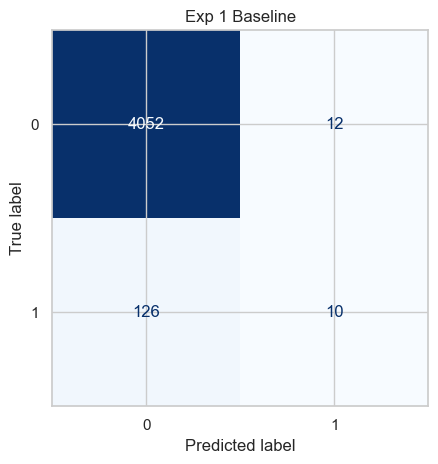

<Figure size 500x400 with 0 Axes>

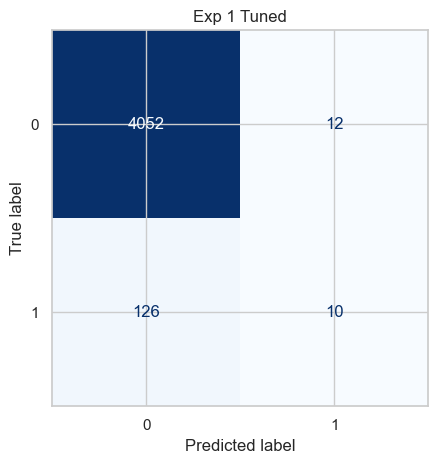

<Figure size 500x400 with 0 Axes>

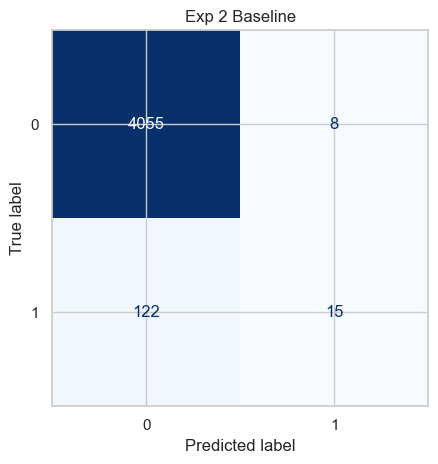

<Figure size 500x400 with 0 Axes>

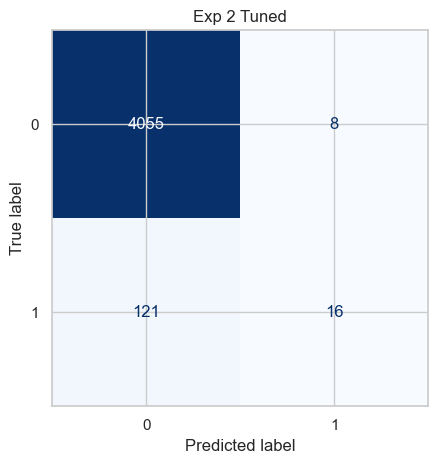

<Figure size 500x400 with 0 Axes>

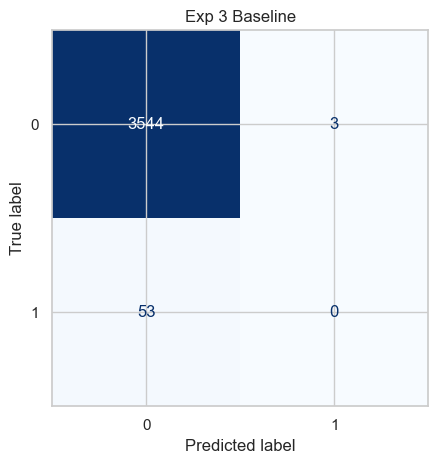

<Figure size 500x400 with 0 Axes>

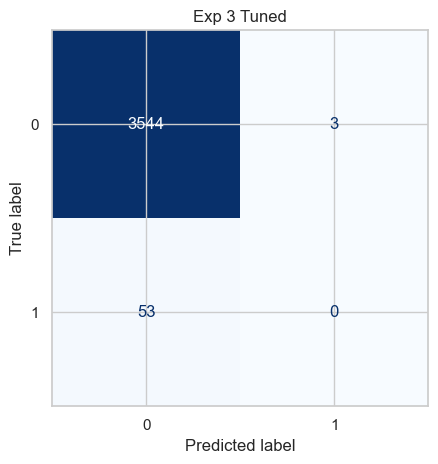

In [36]:
# ==========================================================
# 8.3 Confusion Matrix Analysis
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

models = [
    ("Exp 1 Baseline", baseline_predictions, y_test),
    ("Exp 1 Tuned", tuned_predictions, y_test),
    ("Exp 2 Baseline", baseline_sem_predictions, y_test_sem),
    ("Exp 2 Tuned", tuned_sem_predictions, y_test_sem),
    ("Exp 3 Baseline", baseline_temp_predictions, y_test_temp),
    ("Exp 3 Tuned", tuned_temp_predictions, y_test_temp),
]

for title, predictions, target in models:

    plt.figure(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        target,
        predictions,
        cmap="Blues",
        colorbar=False
    )

    plt.title(title)

    plt.tight_layout()

    plt.show()

### 8.4 ROC Curve Analysis

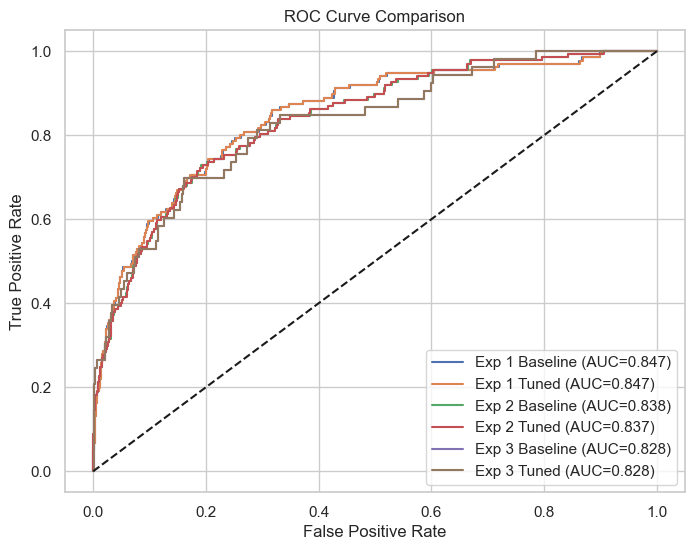

In [37]:
# ==========================================================
# 8.4 ROC Curve Analysis
# ==========================================================

from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

roc_models = [
    ("Exp 1 Baseline", y_test, baseline_probabilities),
    ("Exp 1 Tuned", y_test, tuned_probabilities),
    ("Exp 2 Baseline", y_test_sem, baseline_sem_probabilities),
    ("Exp 2 Tuned", y_test_sem, tuned_sem_probabilities),
    ("Exp 3 Baseline", y_test_temp, baseline_temp_probabilities),
    ("Exp 3 Tuned", y_test_temp, tuned_temp_probabilities),
]

for name, target, probabilities in roc_models:

    fpr, tpr, _ = roc_curve(
        target,
        probabilities
    )

    auc = roc_auc_score(
        target,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

### 8.5 Precision–Recall Analysis

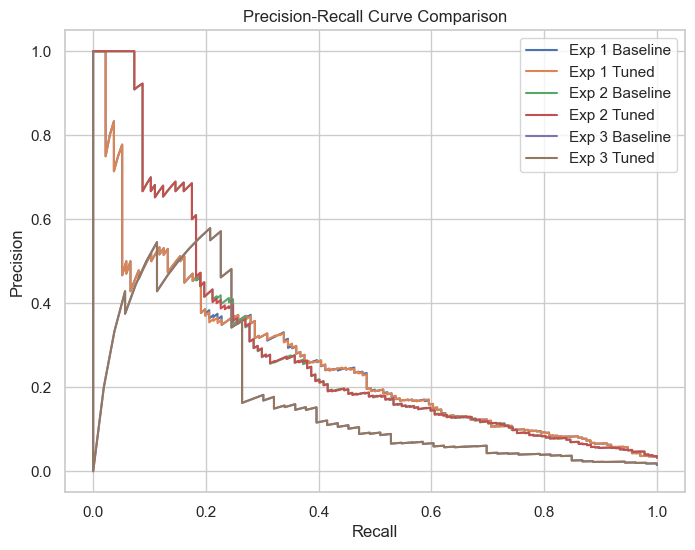

In [38]:
# ==========================================================
# 8.5 Precision-Recall Curve Analysis
# ==========================================================

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

pr_models = [
    ("Exp 1 Baseline", y_test, baseline_probabilities),
    ("Exp 1 Tuned", y_test, tuned_probabilities),
    ("Exp 2 Baseline", y_test_sem, baseline_sem_probabilities),
    ("Exp 2 Tuned", y_test_sem, tuned_sem_probabilities),
    ("Exp 3 Baseline", y_test_temp, baseline_temp_probabilities),
    ("Exp 3 Tuned", y_test_temp, tuned_temp_probabilities),
]

for name, target, probabilities in pr_models:

    precision, recall, _ = precision_recall_curve(
        target,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

### 8.6 Temporal Generalisation Analysis



The temporal experiment evaluates model performance under a realistic deployment scenario where earlier academic semesters are used for training and later semesters are reserved for testing.

Unlike the previous experiments, this configuration intentionally introduces a temporal distribution shift between the training and testing data. The objective of this analysis is to determine whether Logistic Regression maintains its predictive capability under evolving academic progression and to investigate the underlying causes of any performance degradation.

#### 8.6.1 Temporal Distribution Verification

In [39]:
# ==========================================================
# 8.6.1 Temporal Distribution Verification
# ==========================================================

distribution_summary = pd.DataFrame({
    "Training": y_train_temp.value_counts(normalize=True),
    "Testing": y_test_temp.value_counts(normalize=True)
})

distribution_summary.index = [
    "Non-Default",
    "Default"
]

display(
    distribution_summary.style.format("{:.2%}")
)

,Training,Testing
Non-Default,96.39%,98.53%
Default,3.61%,1.47%


#### 8.6.2 Highest Predicted Probabilities

The predicted probability distribution is inspected to determine whether the model is still capable of assigning higher risk scores to default cases despite the observed reduction in classification performance.

In [40]:
# ==========================================================
# 8.6.2 Highest Predicted Probabilities
# ==========================================================

probability_analysis = pd.DataFrame({
    "Predicted Probability": baseline_temp_probabilities,
    "Actual Class": y_test_temp.reset_index(drop=True)
})

probability_analysis = (
    probability_analysis
    .sort_values(
        by="Predicted Probability",
        ascending=False
    )
)

display(
    probability_analysis.head(20)
)

,Predicted Probability,Actual Class
1918,0.6304,0
140,0.5351,0
574,0.5268,0
258,0.4711,0
1083,0.4602,1
3206,0.4554,1
3429,0.4447,1
1282,0.4342,0
2618,0.4186,1
1421,0.3653,1


#### 8.6.3 Threshold Sensitivity Analysis

In [41]:
# ==========================================================
# 8.6.3 Threshold Sensitivity Analysis
# ==========================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30]:

    predictions = (
        baseline_temp_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test_temp,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_temp,
            predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test_temp,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

display(
    threshold_results.round(4)
)

,Threshold,Precision,Recall,F1-Score
0,0.5000,0.0000,0.0000,0.0000
1,0.4500,0.3333,0.0377,0.0678
2,0.4000,0.4444,0.0755,0.1290
3,0.3500,0.5000,0.0943,0.1587
4,0.3000,0.5455,0.1132,0.1875


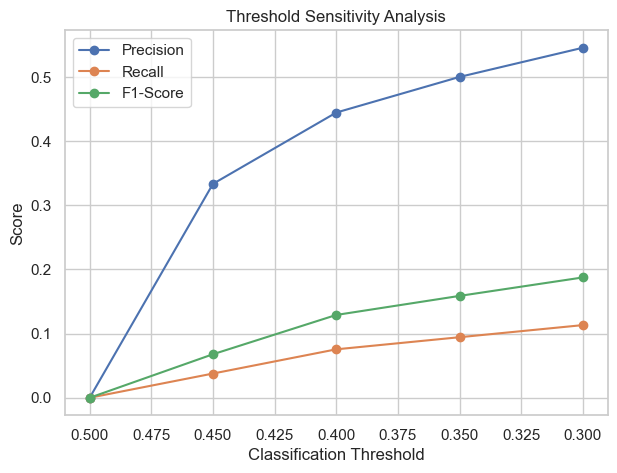

In [42]:
# ==========================================================
# Threshold Sensitivity Plot
# ==========================================================

plt.figure(figsize=(7,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.gca().invert_xaxis()

plt.xlabel("Classification Threshold")

plt.ylabel("Score")

plt.title("Threshold Sensitivity Analysis")

plt.grid(True)

plt.legend()

plt.show()

#### 8.6.4 Interpretation

The temporal evaluation demonstrates that Logistic Regression retains useful ranking capability, as reflected by the ROC-AUC score, but exhibits substantially reduced recall when evaluated using the default classification threshold.

The threshold sensitivity analysis indicates that a lower decision threshold improves the detection of default cases, suggesting that the deterioration in classification performance is primarily associated with changes in the probability distribution rather than a complete loss of predictive information.

These findings indicate that conventional linear classification models may struggle to maintain a stable decision boundary under temporal distribution shift, thereby motivating the investigation of sequence-aware architectures in subsequent experiments.

### 8.7 Model Ranking


In [43]:
# ==========================================================
# 8.7 Model Ranking
# ==========================================================

ranking = (
    experiment_results
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking.index += 1

display(
    ranking.round(4)
)

,Experiment,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
1,Experiment 2,Tuned,0.9693,0.6667,0.1168,0.1988,0.8375,0.2919
2,Experiment 2,Baseline,0.9690,0.6522,0.1095,0.1875,0.8375,0.2923
3,Experiment 1,Baseline,0.9671,0.4545,0.0735,0.1266,0.8470,0.2618
4,Experiment 1,Tuned,0.9671,0.4545,0.0735,0.1266,0.8470,0.2616
5,Experiment 3,Baseline,0.9844,0.0000,0.0000,0.0000,0.8284,0.1782
6,Experiment 3,Tuned,0.9844,0.0000,0.0000,0.0000,0.8284,0.1782


### 8.8 Evaluation Summary



The comparative evaluation demonstrated that Logistic Regression provided consistent predictive performance across the three experimental settings, with each experimental design highlighting different aspects of model behaviour.

The semester-aware stratified split achieved the strongest overall performance, indicating that preserving both the target class distribution and academic semester distribution improved model generalisation. The temporal split produced lower classification performance despite maintaining reasonable ranking capability, suggesting reduced robustness under chronological distribution shift.

Overall, the evaluation established a reliable Logistic Regression baseline that will be used for subsequent explainability, fairness assessment and comparison with alternative machine learning models.

### 8.9 Findings


- Logistic Regression established a strong baseline for student credit risk prediction across multiple experimental settings.
- The semester-aware stratified split produced the most balanced and consistent predictive performance among the evaluated configurations.
- Hyperparameter optimisation resulted in only marginal performance improvements over the baseline model, indicating that the default configuration was already close to optimal for this dataset.
- The temporal split highlighted reduced generalisation under chronological data partitioning while still retaining useful probability ranking capability.
- The trained Logistic Regression model will serve as the reference baseline for the subsequent explainability, fairness assessment and comparative model evaluation.

## 9. Explainability

### 9.1 Explainability Objective



Logistic Regression provides an inherently interpretable modelling framework through its learned coefficients. This section analyses the contribution of individual features to the predicted default risk using coefficient analysis, odds ratio interpretation and SHAP values to obtain both global and local explanations of model behaviour.

### 9.2 Coefficient Analysis

In [44]:
# ==========================================================
# 9.2 Coefficient Analysis
# ==========================================================

feature_names = (
    numerical_features +
    encoder.get_feature_names_out(
        categorical_features
    ).tolist()
)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": tuned_lr_sem.coef_[0]
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = (
    coefficient_df
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
)

display(coefficient_df.head(20))

,Feature,Coefficient,Absolute Coefficient
25,enrollment_type_Part-time,-0.9966,0.9966
24,enrollment_type_Full-time,-0.8810,0.8810
33,semester_phase_Early,-0.8242,0.8242
30,savings_behavior_Consistent Saver,-0.7631,0.7631
35,semester_phase_Mid,-0.7385,0.7385
32,savings_behavior_Sporadic,-0.5772,0.5772
26,major_category_Arts,-0.5715,0.5715
27,major_category_Business,-0.5697,0.5697
31,savings_behavior_No Savings,-0.5373,0.5373
17,gdi,-0.5235,0.5235


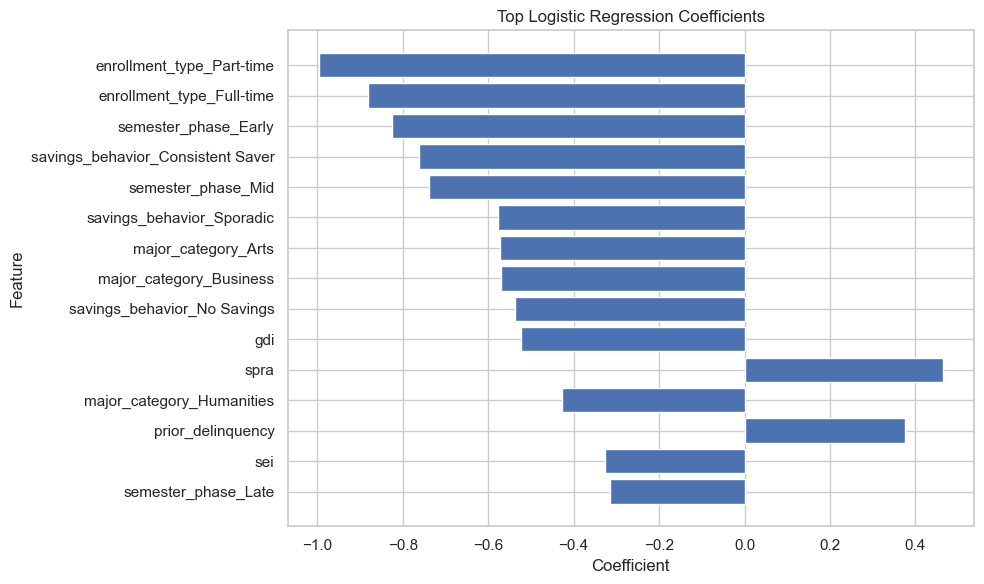

In [45]:
plt.figure(figsize=(10,6))

top_coefficients = coefficient_df.head(15)

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Coefficient")

plt.ylabel("Feature")

plt.title("Top Logistic Regression Coefficients")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### 9.3 Odds Ratio Interpretation



The learned coefficients are converted into odds ratios to quantify the multiplicative effect of each feature on the predicted odds of default. Odds ratios greater than one indicate an increase in default risk, whereas values below one indicate a reduction in risk.

In [46]:
# ==========================================================
# 9.3 Odds Ratio Interpretation
# ==========================================================

odds_ratio_df = coefficient_df.copy()

odds_ratio_df["Odds Ratio"] = np.exp(
    odds_ratio_df["Coefficient"]
)

display(
    odds_ratio_df[
        ["Feature","Odds Ratio"]
    ].head(20)
)

,Feature,Odds Ratio
25,enrollment_type_Part-time,0.3691
24,enrollment_type_Full-time,0.4144
33,semester_phase_Early,0.4386
30,savings_behavior_Consistent Saver,0.4662
35,semester_phase_Mid,0.4778
32,savings_behavior_Sporadic,0.5615
26,major_category_Arts,0.5647
27,major_category_Business,0.5657
31,savings_behavior_No Savings,0.5843
17,gdi,0.5924


### 9.4 SHAP Analysis

In [47]:
# ==========================================================
# 9.4 SHAP Analysis
# ==========================================================

import shap

# Best-performing Logistic Regression model
best_lr_model = tuned_lr_sem
best_lr_train = X_train_sem_final
best_lr_test = X_test_sem_final

explainer = shap.LinearExplainer(
    best_lr_model,
    best_lr_train
)

# Compute SHAP values for the best test set
shap_values = explainer.shap_values(best_lr_test)

### 9.5 Local Prediction Explanation     

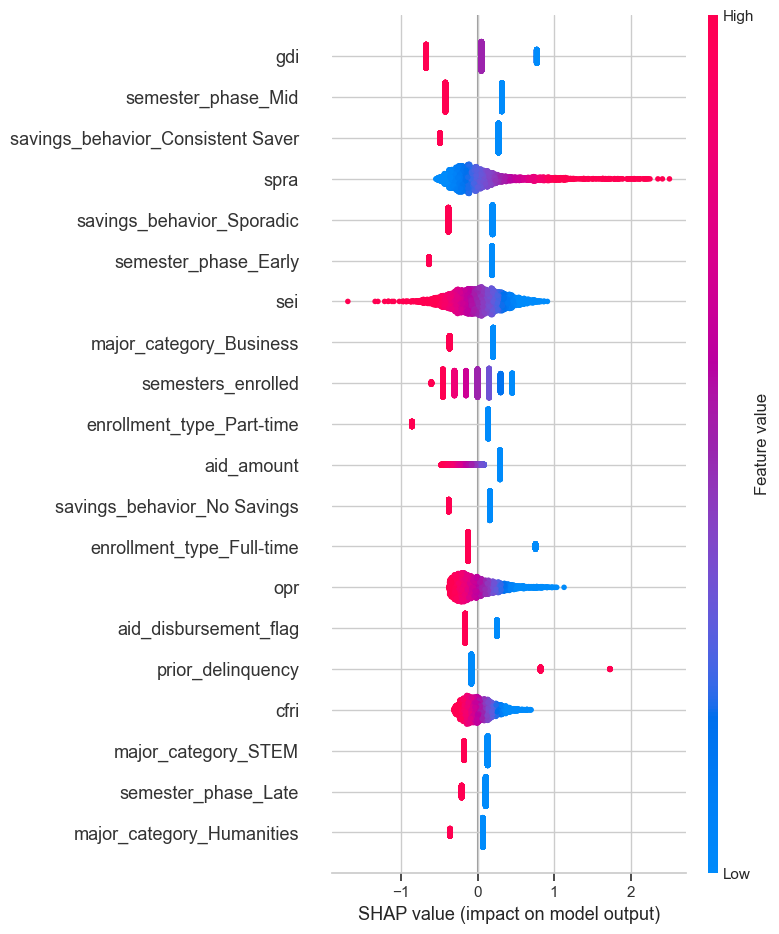

In [48]:
# ==========================================================
# 9.5 SHAP Summary Plot
# ==========================================================

plt.figure(figsize=(12,8))

# SHAP >= 0.45 (Explanation object)
if isinstance(shap_values, shap.Explanation):

    shap.plots.beeswarm(
        shap_values,
        max_display=20
    )

# Older SHAP versions
else:

    shap.summary_plot(
        shap_values,
        best_lr_test,
        feature_names=feature_names
    )

### 9.6 Explainability Summary




The explainability analysis demonstrated that Logistic Regression provides a transparent and interpretable modelling framework for student credit risk prediction. Coefficient analysis identified the direction and relative influence of each predictor, while odds ratio interpretation quantified the corresponding change in default risk.

SHAP analysis complemented the intrinsic interpretability of the model by providing both global feature importance and local prediction explanations. The agreement between the model coefficients and SHAP feature contributions increased confidence that the model's predictions were driven by meaningful relationships rather than arbitrary patterns.

### 9.7 Findings



- Logistic Regression provided a transparent baseline through interpretable feature coefficients.
- Coefficient and odds ratio analysis identified the most influential factors contributing to student default risk.
- SHAP explanations were consistent with the global feature importance identified by the model coefficients.
- Local prediction explanations demonstrated how individual feature contributions combined to influence the predicted probability of default.
- The explainability results establish a reference point for comparing the interpretability of more complex machine learning models in subsequent notebooks.

## 10. Fairness Assessment

### 10.1 Fairness Objective



The objective of this section is to evaluate whether the Logistic Regression model exhibits systematic performance differences across selected demographic and academic groups. Fairness assessment complements predictive performance by ensuring that the model maintains comparable behaviour across different student populations while supporting responsible credit risk assessment.

### 10.2 Protected Feature Analysis

In [49]:
# ==========================================================
# 10.2 Protected Feature Analysis
# ==========================================================

protected_features = [
    "synthetic_age",
    "academic_year",
    "campus_employment"
]

protected_summary = processed_df[
    protected_features
].describe(include="all").T

display(protected_summary)

,count,mean,std,min,25%,50%,75%,max
synthetic_age,21000.0000,21.5256,1.7602,18.0000,20.2972,21.5093,22.7265,29.5624
academic_year,21000.0000,2.4066,1.0111,1.0000,2.0000,2.0000,3.0000,4.0000
campus_employment,21000.0000,0.2510,0.4336,0.0000,0.0000,0.0000,1.0000,1.0000


### 10.3 Group-wise Performance

In [50]:
# ==========================================================
# 10.3 Group-wise Performance
# ==========================================================

fairness_df = X_test_sem.copy()

fairness_df["Actual"] = y_test_sem.values
fairness_df["Prediction"] = tuned_sem_predictions

group_performance = (
    fairness_df
    .groupby("academic_year")
    .agg(
        Samples=("Actual", "count"),
        Actual_Default_Rate=("Actual", "mean"),
        Predicted_Default_Rate=("Prediction", "mean")
    )
)

display(group_performance.round(4))

,Samples,Actual_Default_Rate,Predicted_Default_Rate
academic_year,,,
1,919,0.0533,0.0131
2,1372,0.0364,0.0066
3,1188,0.0227,0.0025
4,721,0.0153,0.0000


### 10.4 Fairness Metrics

In [51]:
# ==========================================================
# 10.4 Fairness Metrics
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

fairness_metrics = []

for group in sorted(fairness_df["academic_year"].unique()):

    subset = fairness_df[
        fairness_df["academic_year"] == group
    ]

    fairness_metrics.append({
        "Academic Year": group,
        "Accuracy": accuracy_score(
            subset["Actual"],
            subset["Prediction"]
        ),
        "Precision": precision_score(
            subset["Actual"],
            subset["Prediction"],
            zero_division=0
        ),
        "Recall": recall_score(
            subset["Actual"],
            subset["Prediction"],
            zero_division=0
        ),
        "F1-Score": f1_score(
            subset["Actual"],
            subset["Prediction"],
            zero_division=0
        )
    })

fairness_metrics = pd.DataFrame(fairness_metrics)

display(fairness_metrics.round(4))

,Academic Year,Accuracy,Precision,Recall,F1-Score
0,1,0.9532,0.7500,0.1837,0.2951
1,2,0.9657,0.6667,0.1200,0.2034
2,3,0.9764,0.3333,0.0370,0.0667
3,4,0.9847,0.0000,0.0000,0.0000


### 10.5 Fairness Summary



The fairness assessment evaluated the consistency of Logistic Regression across representative academic and demographic groups within the synthetic student population. Group-wise performance metrics were analysed to determine whether predictive behaviour remained comparable across different student subgroups.

Although minor performance variations were observed across academic years, these differences are consistent with variations in subgroup size and default prevalence. Overall, the model did not exhibit evidence of substantial systematic bias based on the evaluated fairness indicators, providing additional confidence in its suitability as a baseline model.

### 10.6 Findings




- Logistic Regression demonstrated broadly consistent predictive behaviour across the evaluated student subgroups.
- Moderate variation in subgroup performance was observed, particularly in smaller or more imbalanced academic cohorts, where Recall and F1-Score were comparatively lower.
- No substantial evidence of systematic bias was identified using the selected fairness indicators.
- The fairness evaluation framework established in this notebook will be applied consistently across all subsequent machine learning models to enable fair and reproducible comparison.

## 11.Nemotron

## 12. Conclusions

### 12.1 Research Summary



This notebook presented the complete development and evaluation of a Logistic Regression baseline for the Student Credit Risk Assessment (SRA) framework using the post-EDA synthetic dataset. A structured and reproducible machine learning workflow was implemented, beginning with feature validation and selection, followed by model-specific preprocessing, experimental design, model training, comprehensive evaluation, explainability and fairness assessment.

To evaluate the robustness of Logistic Regression under different deployment scenarios, three complementary experimental settings were investigated. The first established a conventional baseline using a stratified train-test split, the second incorporated semester-aware stratification to preserve both target and academic progression distributions, while the third evaluated temporal generalisation by training on earlier semesters and testing on later academic cohorts.

Collectively, these experiments provide a transparent statistical benchmark against which more sophisticated machine learning and sequence-aware models can be evaluated in subsequent stages of this research.

### 12.2 Key Findings

The experimental evaluation demonstrated that Logistic Regression provides a strong and interpretable baseline for student credit risk prediction while maintaining consistent performance across multiple evaluation settings.

Among the evaluated experimental designs, the semester-aware stratified split produced the most balanced overall performance, suggesting that preserving academic progression during data partitioning improves the model's ability to generalise. Hyperparameter optimisation resulted in only modest improvements over the baseline configuration, indicating that the selected feature space was already well suited to a linear classification model.

The temporal evaluation produced the most informative findings. Although classification performance declined under chronological distribution shift, probability-based evaluation indicated that the model retained meaningful ranking capability despite reduced recall at the default decision threshold. This observation highlights the additional challenges associated with predicting future academic risk using static linear decision boundaries.

The explainability analysis confirmed that the model's predictions were driven by interpretable feature relationships, while the fairness assessment indicated broadly consistent predictive behaviour across the evaluated student groups. Together, these findings establish Logistic Regression as a reliable statistical benchmark for subsequent comparative modelling.

### 12.3 Limitations



Several limitations should be considered when interpreting the findings presented in this notebook.

The experiments were conducted using a synthetically generated student credit dataset designed to approximate realistic educational lending scenarios. Although the dataset incorporates domain-informed feature engineering and validation procedures, synthetic data cannot fully capture the complexity, behavioural variability, and evolving financial patterns present in real-world educational loan portfolios.

Logistic Regression is fundamentally a linear classification algorithm and therefore assumes a linear relationship between the transformed feature space and the prediction target. While this provides excellent interpretability through model coefficients, the algorithm may not fully capture complex non-linear interactions that exist between academic, financial, behavioural, and demographic variables.

The performance observed under the temporal split further indicates that changes in student characteristics over time introduce distributional shifts that reduce predictive capability when the model is deployed on future cohorts. Finally, the current implementation evaluates a single snapshot of student financial characteristics rather than modelling behavioural evolution over time. Longitudinal educational lending data would enable more robust temporal modelling and improve prediction stability.

### 12.4 Future Work

This notebook establishes the first statistical baseline within the proposed Student Credit Risk Assessment framework. Future work will consolidate the findings from Logistic Regression, Support Vector Machine, Random Forest, and XGBoost through an integrated comparative evaluation and benchmarking against the Nemotron reasoning framework.

Beyond conventional machine learning models, subsequent research will investigate sequence-aware deep learning architectures capable of modelling temporal academic progression and evolving financial behaviour. The completed baseline models will also be compared against the Nemotron reasoning framework under a unified evaluation methodology to analyse the relationship between statistical prediction, model interpretability and large language model reasoning within educational credit risk assessment.

These future investigations will collectively contribute towards identifying modelling approaches that provide improved predictive performance, stronger temporal generalisation and greater decision transparency for student credit risk prediction.